# clean_swaps

In [ ]:
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr
from util import (
    pose_df_to_movement_ds,
    plot_speed,
    shade_mask_regions,
    clean_swaps_refactor,
)
from aeon.dj_pipeline import fetch_stream, tracking, acquisition
from aeon.dj_pipeline.utils import tracking_utils
from matplotlib import pyplot as plt
from movement.kinematics import compute_speed, compute_pairwise_distances
from movement.transforms import scale

2025-06-24 10:19:05.669 | WARNING  | pkg_resources:<module>:98 - c:\Users\locha\Documents\Work\swc-aeon_analysis\.venv\Lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources

[2025-06-24 10:20:03,355][INFO]: DataJoint 0.14.4 connected to chuan@localhost:3306


## Query centroid data from the database

### social0.2-aeon3

In [159]:
start_time = pd.Timestamp("2024-02-09 17:00:00")
end_time = start_time + pd.Timedelta(minutes=10)
key = {
    "experiment_name": "social0.2-aeon3",
    "chunk_start": start_time.floor("h"),
}

### social0.4-aeon4

In [167]:
start_time = pd.Timestamp("2024-08-28 21:00:00")
end_time = start_time + pd.Timedelta(hours=1)
key = {
    "experiment_name": "social0.4-aeon4",
    "chunk_start": start_time.floor("h"),
}

In [168]:
centroid_query = (
    tracking.SLEAPTracking.PoseIdentity.proj("identity_name", "identity_likelihood")
    * tracking.SLEAPTracking.AnchorPart
    & key
)
df = fetch_stream(centroid_query)[start_time:end_time]
df = df.sort_index()
ids = df["identity_name"].unique()
active_region_query = acquisition.EpochConfig.ActiveRegion & (acquisition.Chunk & key)
region_df = active_region_query.fetch(format="frame")

[2025-06-24 12:46:10,138][WARNING]: Reconnecting to MySQL server.


In [326]:
df_raw = df.copy(deep=True)
df_clean = tracking_utils.clean_swaps(df_raw, region_df)
df_adjusted = clean_swaps_refactor2(df_raw, region_df)
df_raw.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_raw["part"] = "centroid"
df_adjusted.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_adjusted["part"] = "centroid"
df_clean.rename(
    columns={
        "identity_name": "identity",
        "likelihood": "part_likelihood",
    },
    inplace=True,
)
df_clean["part"] = "centroid"
df_clean.equals(df_adjusted)

Cleaning frames: 100%|██████████| 180000/180000 [00:01<00:00, 99891.77it/s] 


Cleaning frames:   0%|          | 0/180000 [00:00<?, ?it/s]

False

## Convert to movement dataset

In [327]:
ds_centroid = pose_df_to_movement_ds(df_raw)
ds_centroid_clean = pose_df_to_movement_ds(df_clean).reindex_like(ds_centroid)
ds_centroid_adjusted = pose_df_to_movement_ds(df_adjusted).reindex_like(ds_centroid)

## Plot position and inter-mouse distances

In [ ]:
def find_nan_runs(arr, min_length=1):
    """Return list of (start, end) indices for consecutive NaN runs in a 1D array."""
    isnan = np.isnan(arr)
    # Pad with False at both ends to catch runs at edges
    padded = np.concatenate([[False], isnan, [False]])
    diff = np.diff(padded.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    runs = list(zip(starts, ends))
    if min_length > 1:
        runs = [(s, e) for s, e in runs if (e - s) >= min_length]
    return runs


print(find_nan_runs(x_clean[0], 100))

[(4005, 4115), (8004, 8124), (8575, 10896), (24447, 24593), (24643, 26517)]


In [ ]:
diff_frames = (
    (diff_mask.where(diff_mask, drop=True).time - ds_centroid.time.values[0]).values
    / np.timedelta64(1, "s")
    * 50
).astype(int)

In [349]:
diff_frames

array([ 32855,  33374,  34235,  35207,  35390,  35403,  35408,  35431,
        36486,  36551,  36651,  36654,  36828,  37208,  47045,  47081,
        47082,  47083,  47084,  47085,  47086,  47087,  47088,  47089,
        47090,  47091,  47092,  47093,  47094,  47095,  47096,  47097,
        47098,  47099,  47100,  47101,  47102,  47268,  47288,  47387,
        47390,  48045,  48470,  48676,  48697,  51604,  51611,  51644,
        52186,  52187,  52195,  52254,  52387,  52395,  52396,  52397,
        52417,  52534,  52535,  52536,  52537,  52538,  52539,  52540,
        52541,  52541,  52542,  52544,  52545,  52546,  52621,  53677,
        53685,  53887,  54695,  55755,  62798,  65242,  66131,  77953,
        77954, 105128, 105168, 106161, 106239, 106314, 106351, 106359,
       121210, 155586, 155591, 155604, 155605, 155606, 156462])

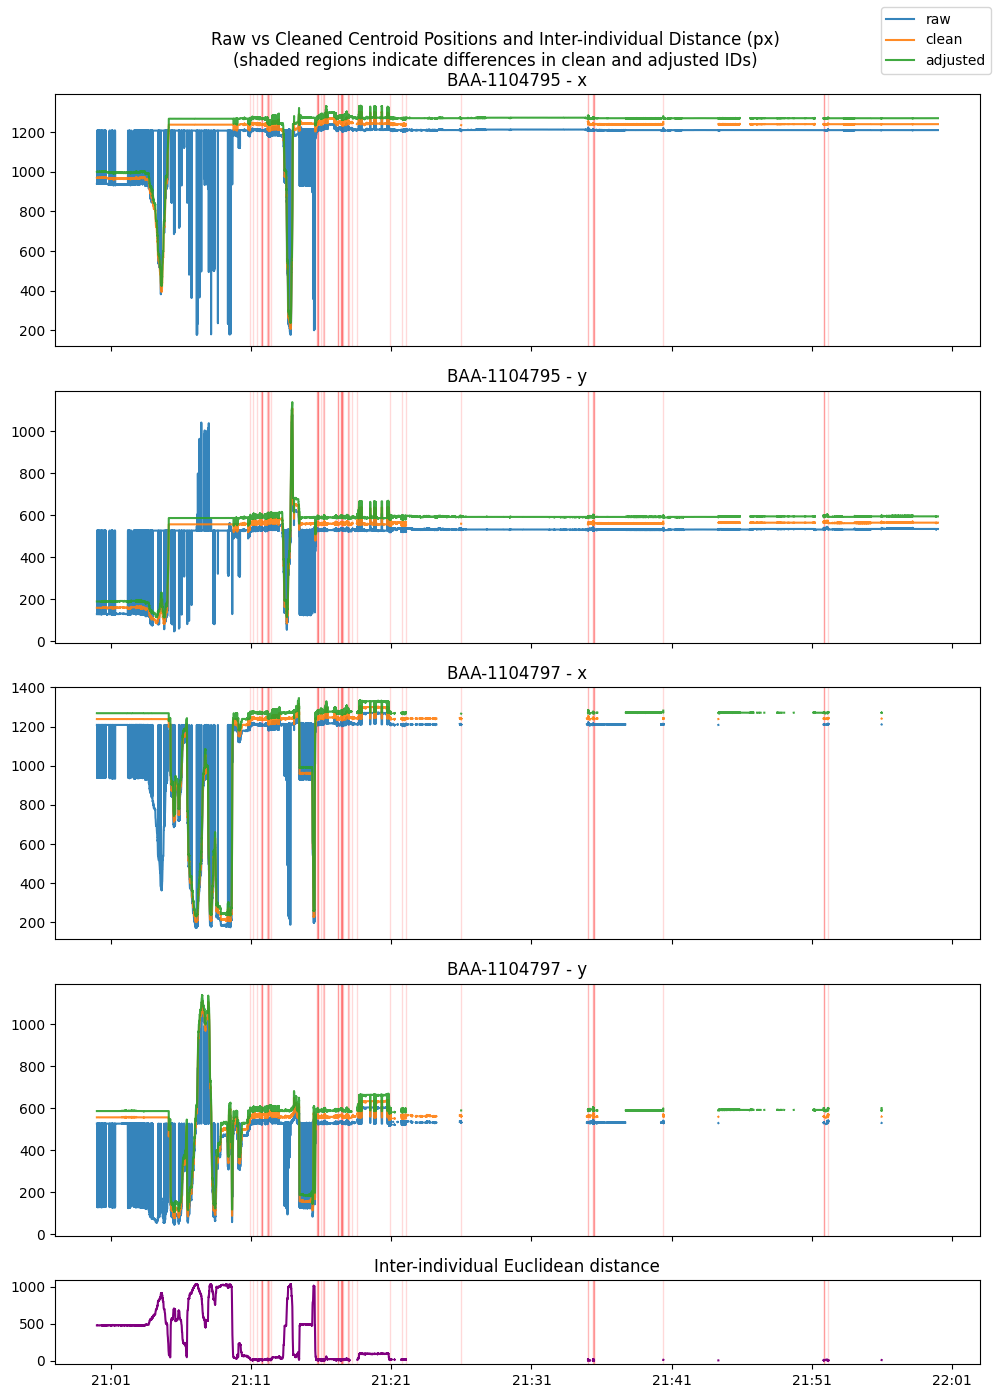

In [347]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = xr.DataArray(
    (
        ~np.isclose(
            ds_centroid_clean.position.squeeze(),
            ds_centroid_adjusted.position.squeeze(),
            equal_nan=True,
        )
        & ~np.isnan(ds_centroid_clean.position.squeeze())
    )[:, 0, 0],
    dims=["time"],
    coords={"time": ds_centroid_clean.time},
)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and adjusted IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

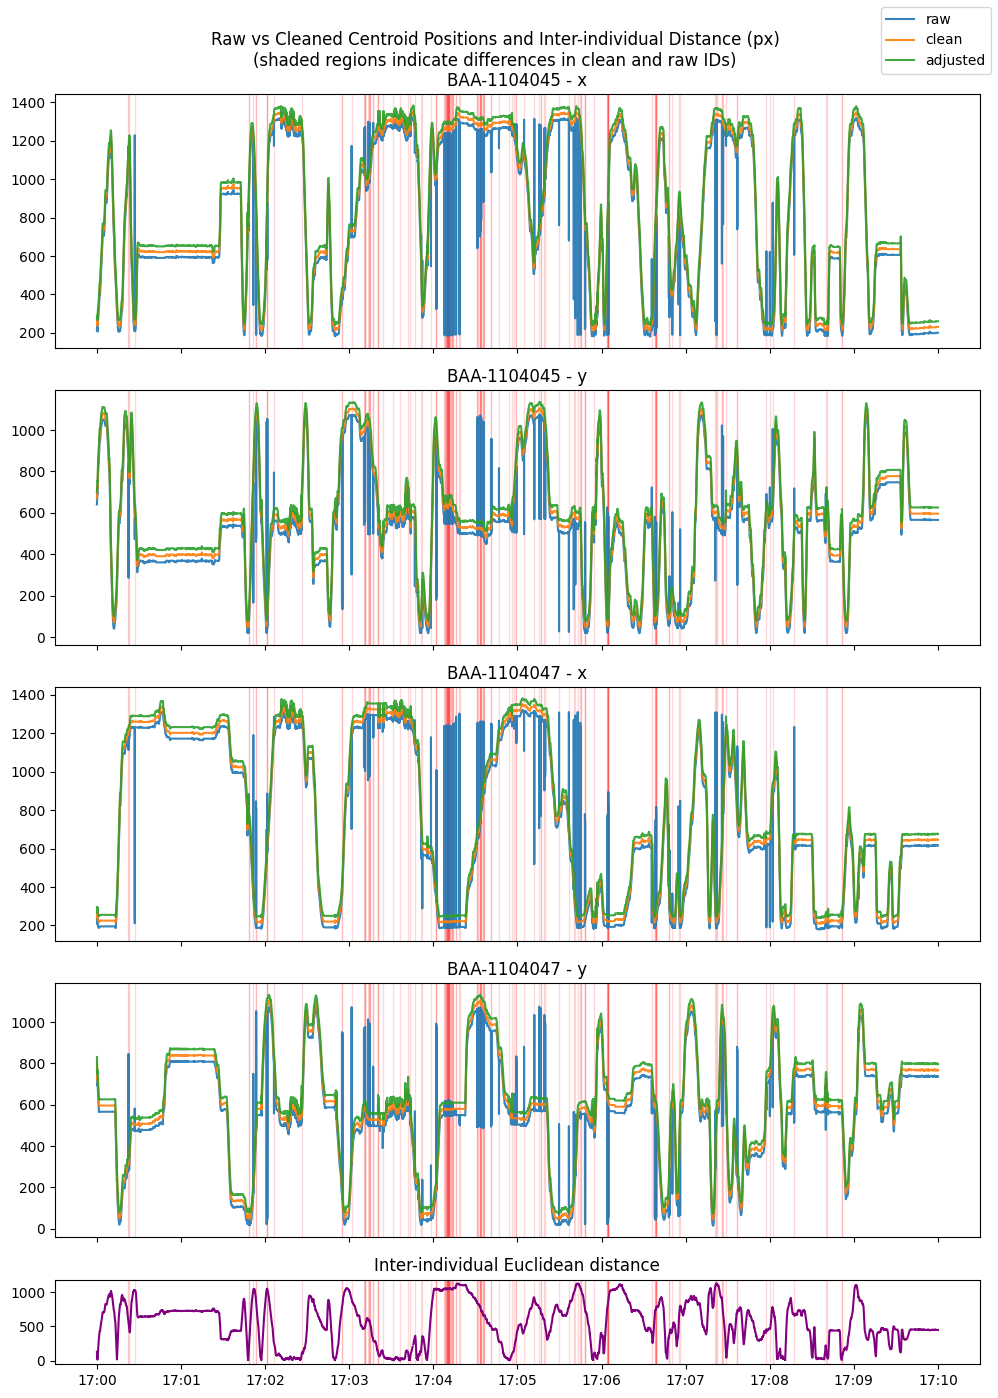

In [229]:
# Compute the difference mask between cleaned and adjusted IDs
diff_mask = xr.DataArray(
    (
        ~np.isclose(
            ds_centroid_clean.position.squeeze(),
            ds_centroid.position.squeeze(),
            equal_nan=True,
        )
    )[:, 0, 0],
    dims=["time"],
    coords={"time": ds_centroid_clean.time},
)
# Compute inter-individual distances for the cleaned dataset
inter_ind_dist = compute_pairwise_distances(
    ds_centroid_clean.position, dim="individuals", pairs="all", metric="euclidean"
)
# Plot
spaces = ds_centroid.space.values
individuals = ds_centroid.individuals.values
nrows = len(individuals) * len(spaces)
ncols = 1
# Add 1 extra row for the inter-individual distance plot, make it shorter
height_ratios = [3] * nrows + [1]
fig, axes = plt.subplots(
    nrows=nrows + 1,
    ncols=ncols,
    figsize=(10, 3 * nrows + 2),
    sharex=True,
    gridspec_kw={"height_ratios": height_ratios},
)
axes = np.array(axes).reshape(-1)
offsets = [0, 30, 60]
datasets = [
    (ds_centroid, "raw", offsets[0]),
    (ds_centroid_clean, "clean", offsets[1]),
    (ds_centroid_adjusted, "adjusted", offsets[2]),
]
# Main plots
for i, ind in enumerate(individuals):
    for j, space in enumerate(spaces):
        ax_idx = i * len(spaces) + j
        ax = axes[ax_idx]
        for ds, label, offset in datasets:
            y = ds.position.squeeze().sel(space=space, individuals=ind)
            ax.plot(
                y.time,
                y + offset,
                linestyle="-",
                alpha=0.9,
                label=label if (ind == individuals[0] and space == spaces[0]) else None,
            )
        ax.set_title(f"{ind} - {space}")
        # Shade regions where IDs differ
        shade_mask_regions(ax, diff_mask)

# Inter-individual distance plot (bottom row)
ax_dist = axes[-1]
ax_dist.plot(
    inter_ind_dist.time,
    inter_ind_dist.values,
    color="purple",
)
# Shade regions where IDs differ
shade_mask_regions(ax_dist, diff_mask)
ax_dist.set_title("Inter-individual Euclidean distance")
# Shared legend for the main plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["raw", "clean", "adjusted"],
)
fig.suptitle(
    "Raw vs Cleaned Centroid Positions and Inter-individual Distance (px)\n"
    "(shaded regions indicate differences in clean and raw IDs)",
)
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

## Compute and plot speed (cm/s)

In [330]:
PIXEL_SCALE = 0.192  # 1 px = 0.192 cm
# Compute speed in cm/s for both raw and cleaned centroid positions
ds_centroid["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid.time,
)
ds_centroid_clean["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid_clean.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid_clean.time,
)
ds_centroid_adjusted["speed_cm_per_sec"] = compute_speed(
    scale(
        ds_centroid_adjusted.position.set_index(time="seconds_elapsed"),
        factor=PIXEL_SCALE,
        space_unit="cm",
    )
).assign_coords(
    time=ds_centroid_adjusted.time,
)

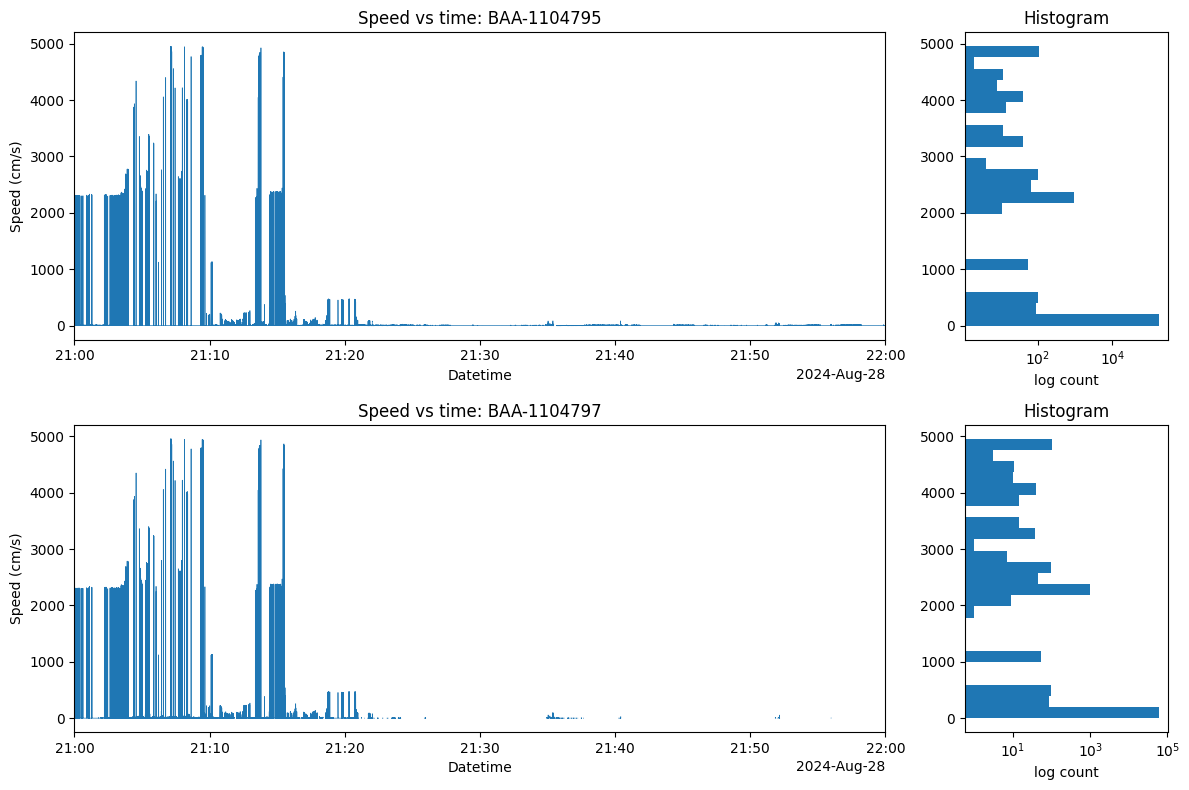

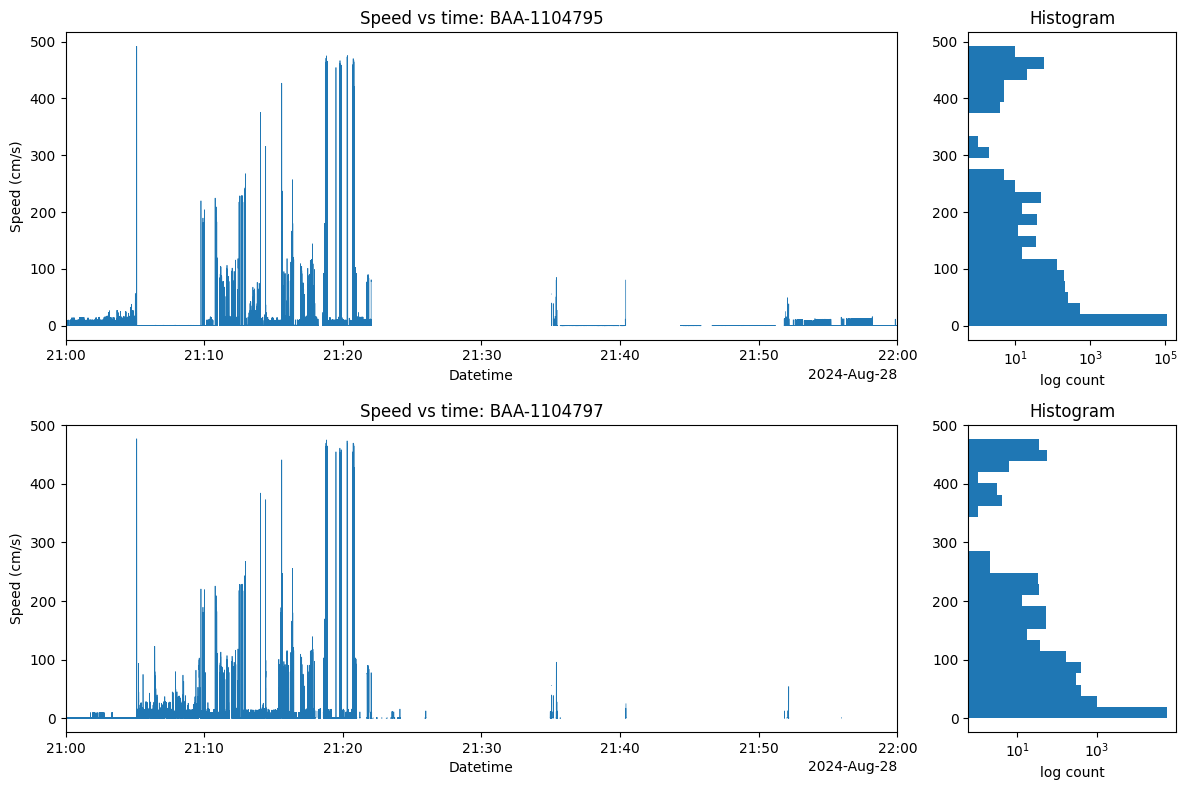

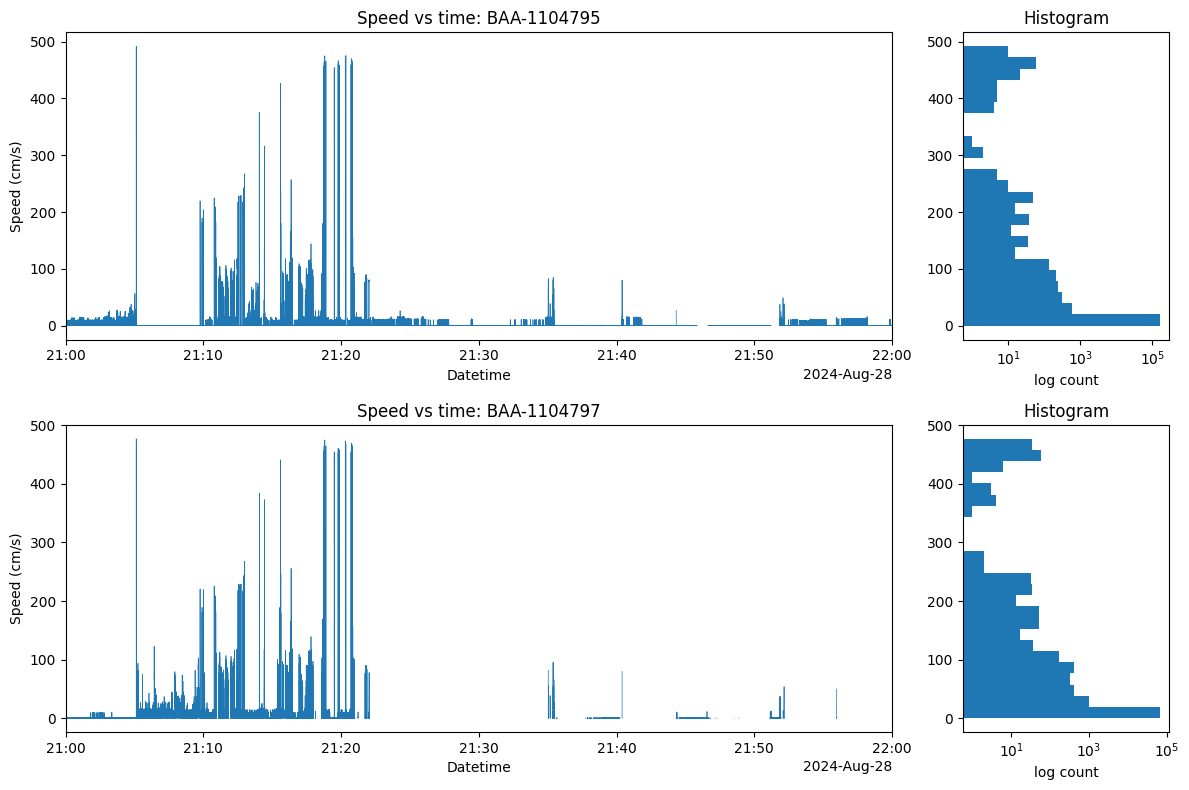

In [331]:
plot_speed(ds_centroid.speed_cm_per_sec.sel(keypoints="centroid"))
plot_speed(ds_centroid_clean.speed_cm_per_sec.sel(keypoints="centroid"))
plot_speed(ds_centroid_adjusted.speed_cm_per_sec.sel(keypoints="centroid"))

## Save to netCDF file for visualisation in movement GUI

In [ ]:
ds_centroid.to_netcdf("raw-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc")
ds_centroid_clean.to_netcdf("clean-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc")
ds_centroid_adjusted.to_netcdf(
    "review-clean-centroid_2024-02-09-17-00-00_social0.2-aeon3.nc"
)

In [329]:
ds_centroid.to_netcdf("raw-centroid_2024-08-28-21-00-00_social0.4-aeon4.nc")
ds_centroid_clean.to_netcdf("clean-centroid_2024-08-28-21-00-00_social0.4-aeon4.nc")
ds_centroid_adjusted.to_netcdf(
    "review-clean-centroid_2024-08-28-21-00-00_social0.4-aeon4.nc"
)